In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_xai import ChatXAI
from pydantic import BaseModel,Field


C:\Users\Archi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%pip install -qU langchain-xai python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Archi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [3]:
load_dotenv()

True

In [4]:
class llm_parallel_workflow(BaseModel):

    score:int = Field(description="This is the score of the participant score out of 10")
    feedback:str = Field(description="This is the feedback of the participant")


In [5]:

import os

from pydantic import SecretStr

from langchain_groq import ChatGroq
model = ChatGroq(model="llama-3.3-70b-versatile", temperature=0,api_key=os.environ.get("API_KEY"))
structured_model = model.with_structured_output(llm_parallel_workflow)

In [6]:
essay = """India s strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI for All) with a focus on inclusive growth, aiming to leverage AI in healthcare, agriculture, education, and smart mobility."""



In [7]:
feedback=structured_model.invoke(essay).score
print(feedback)

8


In [8]:

from typing import Annotated
import operator


In [9]:
 class evaluation(TypedDict):
    cot:str
    dot:str
    language:str
    feedback:str
    essay:str
    total_score:Annotated[list[int],operator.add]


In [10]:
def clarity_of_thought(state:evaluation):
    promt="give feedback on this is essay on basis of clarity of thought" + state['essay']
    cot = model.invoke(promt)
    return { 'cot' : cot}

In [11]:
def deepth_of_thought(state:evaluation):
    promt="give feedback on this is essay on basis of deepth of essay \n {state['essay']}"
    dot = model.invoke(promt)
    return { 'dot': dot}

In [12]:
def language(state:evaluation):
    promt="give feedback on this is essay on basis of language quality of essay /n state['essay']"
    lang = model.invoke(promt)
    return { 'language': lang}

In [13]:
def feedback(state:evaluation):
    promt="give overall feedback"+state['essay']
    feedback = model.invoke(promt)
    return {'feedback': feedback}

In [14]:
from langgraph.graph import StateGraph, START, END

In [15]:
graph = StateGraph(evaluation)

In [16]:
graph.add_node("language",language)
graph.add_node("clarity_of_thought",clarity_of_thought)
graph.add_node("deepth_of_thought",deepth_of_thought)
graph.add_node("feedback",feedback)
graph.add_edge(START,"language")
graph.add_edge(START,"clarity_of_thought")
graph.add_edge(START,"deepth_of_thought")
graph.add_edge("language","feedback")
graph.add_edge("clarity_of_thought","feedback")

In [17]:
graph.add_edge("deepth_of_thought","feedback")
graph.add_edge("feedback",END)

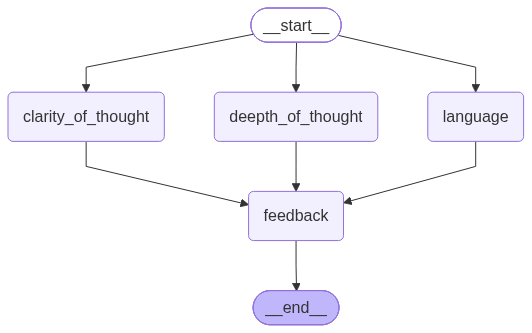

In [18]:
graph.compile()

In [19]:
initial_state ={
    essay:essay


}

In [20]:
workflow = graph.compile()

In [21]:
workflow.invoke(initial_state)

KeyError: 'essay'